# Frequency Analysis

In [616]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt

In [617]:
df = pd.read_csv('output_clean.csv')
df.shape

(241, 72)

In [618]:
df.columns.tolist()

['source_file',
 'documenter_name',
 'fact_checker',
 'hearing_date',
 'arrived_at',
 'left_at',
 'judge_header',
 'courtroom_number',
 'repeated_arguments',
 'general_observations',
 'courthouse_navigator',
 'ability_to_hear',
 'courtroom_has_windows',
 'courtroom_type',
 'case_number',
 'time_hearing_began',
 'time_hearing_ended',
 'judge_case',
 'prosecutor',
 'defense_attorney',
 'defense_attorney_type',
 'accused_person_initials',
 'accused_gender_presentation',
 'accused_perceived_race',
 'pretrial_failure_to_appear',
 'pretrial_new_criminal_activity',
 'pretrial_supervision_score',
 'primary_charge',
 'additional_charges',
 'arrest_datetime',
 'arrest_location',
 'reason_for_contact',
 'gun_found',
 'gun_location',
 'other_arrest_facts',
 'state_narrative',
 'defense_narrative',
 'judge_3_prongs',
 'family_present',
 'family_who',
 'judge_comments_on_family',
 'dependants_spouse_job',
 'other_info_about_person',
 'outcome',
 'source_file_clean',
 'judge_header_clean',
 'judge_ca

In [619]:
[i for i in df.columns.tolist() if 'clean' in i]

['source_file_clean',
 'judge_header_clean',
 'judge_case_clean',
 'arrived_at_clean',
 'left_at_clean',
 'time_hearing_began_clean',
 'time_hearing_ended_clean',
 'ability_to_hear_clean',
 'courtroom_has_windows_clean',
 'courtroom_type_clean',
 'prosecutor_clean',
 'defense_attorney_clean',
 'defense_attorney_type_clean',
 'accused_gender_presentation_clean',
 'accused_perceived_race_clean',
 'pretrial_supervision_score_clean__value',
 'pretrial_supervision_score_clean__is_monitoring',
 'pretrial_failure_to_appear_clean',
 'pretrial_new_criminal_activity_clean',
 'pretrial_supervision_score_clean',
 'primary_charge_clean',
 'arrest_datetime_clean__date',
 'arrest_datetime_clean__time',
 'dependants_spouse_job__has_children_clean',
 'dependants_spouse_job__has_job_clean',
 'dependants_spouse_job__has_spouse_clean',
 'outcome_clean',
 'outcome_clean__electronic_monitoring']

In [620]:
# How many court hearing dates? 
print(df['hearing_date'].nunique())
df['hearing_date'].unique()

12


<StringArray>
['2026-03-12', '2026-03-23', '2026-03-24', '2026-04-08', '2026-04-01',
 '2026-04-10', '2026-04-14', '2026-04-15', '2026-04-19', '2026-04-02',
 '2026-04-20', '2026-04-30']
Length: 12, dtype: str

In [621]:
# Establish a logic for selecting a single note record per date and hearing room 
# Simple logic: pick the record with the least null values AND most number of cases

# Relevant differentiating columns: hearing_date, source_file_room, case_number

df["case_number"] = df["case_number"].astype(str).str.strip().str.upper()
df["source_file_room"] = df["source_file_clean"].str.strip().str.lower()
df["hearing_date"] = pd.to_datetime(df["hearing_date"], errors="coerce")

In [622]:
dupes = (
    df.groupby(["hearing_date", "case_number", "source_file_clean"])
      .size()
      .reset_index(name="n")
      .sort_values("n", ascending=False)
)

dupes.head(10)

,hearing_date,case_number,source_file_clean,n
0,2026-03-12,1,['Overflow'],2
94,2026-04-20,3,['Overflow'],2
90,2026-04-20,10,['Overflow'],2
89,2026-04-20,1,['Room 102'],2
88,2026-04-20,1,['Overflow'],2
87,2026-04-19,5,['Room 102'],2
86,2026-04-19,4,['Room 102'],2
85,2026-04-19,3,['Room 102'],2
84,2026-04-19,2,['Room 102'],2
83,2026-04-19,1,['Room 102'],2


In [623]:
dupes['n'].value_counts(dropna=False)

n
2    114
1     13
Name: count, dtype: int64

In [624]:
key_notetaker = [
    "hearing_date",
    "source_file_clean",
    "documenter_name"
]

df["header_num_cases_heard"] = (
    df.groupby(key_notetaker)["case_number"]
      .transform("nunique")
)

In [625]:
df["header_num_cases_heard"].value_counts()

header_num_cases_heard
7     56
8     48
5     30
23    23
3     21
21    21
10    20
9     18
1      2
2      2
Name: count, dtype: int64

In [626]:
(
    df.groupby(
        ["hearing_date", "source_file_clean", "documenter_name"]
    )["case_number"]
    .nunique()
    .reset_index(name="header_num_cases_heard")
    .sort_values(
        ["hearing_date", "source_file_clean", "header_num_cases_heard"],
        ascending=[True, True, False]
    )
)

,hearing_date,source_file_clean,documenter_name,header_num_cases_heard
0,2026-03-12,['Overflow'],Carolina Ruiz Baldin,8
1,2026-03-12,['Overflow'],Susie Xu,8
2,2026-03-12,['Room 102'],Beatrice Crist,8
3,2026-03-12,['Room 102'],Eric Chandler,8
4,2026-03-23,['Room 102'],Beatrice Crist,5
5,2026-03-23,['Room 102'],Eric Chandler,5
6,2026-03-24,['Room 102'],Ethan Mathews,7
7,2026-03-24,['Room 102'],Heena Srivastava,7
8,2026-04-01,['Overflow'],Beatrice Crist,8
9,2026-04-01,['Overflow'],Evie Roth,8


In [627]:
UNKNOWN_VALUES = {
    "",
    "unknown",
    "unsure",
    "n/a",
    "na",
    "none"
}

def is_informative(x):
    if pd.isna(x):
        return False

    if isinstance(x, str):
        return x.strip().lower() not in UNKNOWN_VALUES

    return True

df["completeness_score"] = df.apply(
    lambda row: sum(is_informative(v) for v in row),
    axis=1
)

df["completeness_score"].value_counts()

completeness_score
61    23
66    21
63    19
67    17
64    16
62    16
58    15
59    15
65    13
56    13
60    10
55     8
54     8
57     7
70     6
68     5
69     4
52     4
53     4
51     4
48     2
49     2
50     2
72     1
37     1
38     1
71     1
46     1
44     1
45     1
Name: count, dtype: int64

In [628]:
case_key = [
    "hearing_date",
    "case_number",
    "source_file_clean"
]

df["num_matching_rows"] = (
    df.groupby(case_key)["case_number"]
      .transform("size")
)

In [629]:
df_ranked = df.sort_values(
    [
        "header_num_cases_heard",
        "completeness_score"
    ],
    ascending=False
)

df_deduped = (
    df_ranked
    .drop_duplicates(
        subset=[
            "hearing_date",
            "case_number",
            "source_file_clean"
        ],
        keep="first"
    )
)

In [630]:
df_deduped["was_deduped"] = (
    df_deduped["num_matching_rows"] > 1
)

In [631]:
df_deduped["was_deduped"].value_counts()

was_deduped
True     114
False     13
Name: count, dtype: int64

In [632]:
# 127 unique cases were heard
df_deduped.shape

(127, 77)

## Working with df_deduped

In [633]:
df = df_deduped

In [634]:
# How long did Documenters court watch for? How long are pretrial hearings?

time_cols = [
    "arrived_at_clean",
    "left_at_clean",
    "time_hearing_began_clean",
    "time_hearing_ended_clean"
]

for col in time_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

In [635]:
df["courtwatching_length_minutes"] = (
    (df["left_at_clean"] - df["arrived_at_clean"])
    .dt.total_seconds()
    .div(60)
)

df["courtwatching_length_hours"] = (
    (df["left_at_clean"] - df["arrived_at_clean"])
    .dt.total_seconds()
    .div(3600)
)

df["hearing_length_minutes"] = (
    (df["time_hearing_ended_clean"] - df["time_hearing_began_clean"])
    .dt.total_seconds()
    .div(60)
)

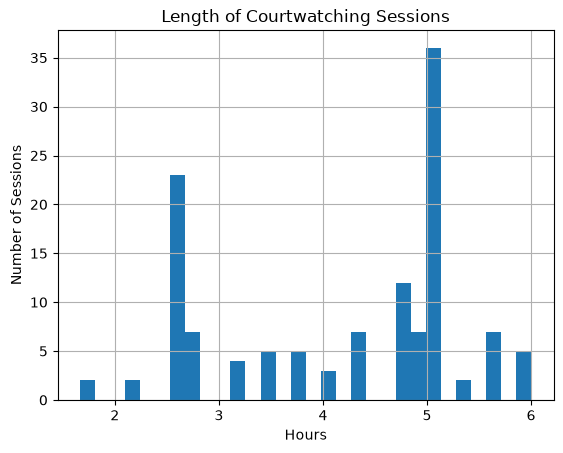

In [636]:
df["courtwatching_length_hours"].dropna().hist(bins=30)

plt.title("Length of Courtwatching Sessions")
plt.xlabel("Hours")
plt.ylabel("Number of Sessions")
plt.show()

In [637]:
df["courtwatching_length_hours"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]
)

count    127.000000
mean       4.197900
std        1.142437
min        1.666667
25%        2.750000
50%        4.750000
75%        5.041667
90%        5.333333
95%        5.666667
max        6.000000
Name: courtwatching_length_hours, dtype: float64

In [638]:
df[df["hearing_length_minutes"]<0]['case_number'].tolist()

[]

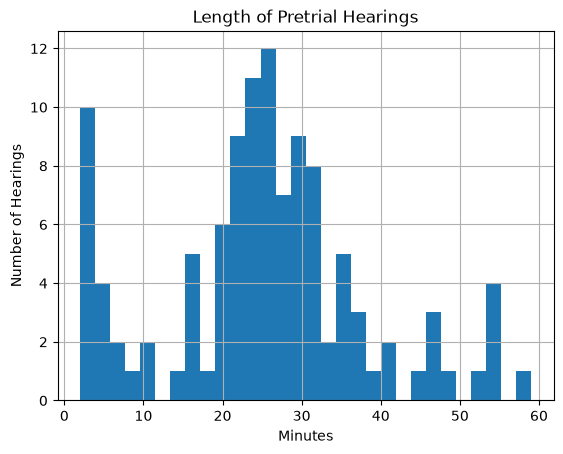

In [639]:
df["hearing_length_minutes"].dropna().hist(bins=30)

plt.title("Length of Pretrial Hearings")
plt.xlabel("Minutes")
plt.ylabel("Number of Hearings")
plt.show()

In [640]:
df["hearing_length_minutes"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]
)

count    112.000000
mean      25.232143
std       13.236574
min        2.000000
25%       20.000000
50%       25.000000
75%       32.000000
90%       40.000000
95%       50.350000
max       59.000000
Name: hearing_length_minutes, dtype: float64

In [641]:
df[df['accused_perceived_race_clean'] == 'Unknown']['source_file'].tolist()

['Circuit Court of Cook County - [in person] 4.30.26 Court Watching_ Notetaking, Overflow Room 04_30_2026_Eric_Chandler.docx',
 'Circuit Court of Cook County - [in person] 4.30.26 Court Watching_ Notetaking, Overflow Room 04_30_2026_Eric_Chandler.docx',
 'Circuit Court of Cook County - [in person] 4.30.26 Court Watching_ Notetaking, Overflow Room 04_30_2026_Eric_Chandler.docx',
 'Circuit Court of Cook County - [in person] 4.30.26 Court Watching_ Notetaking, Overflow Room 04_30_2026_Eric_Chandler.docx',
 'Circuit Court of Cook County - [in person] 4.30.26 Court Watching_ Notetaking, Overflow Room 04_30_2026_Eric_Chandler.docx',
 'Circuit Court of Cook County - [in person] 4.20.26 Court Watching_ Notetaking, Overflow Room 04_20_2026_Zerricka_Burton.docx',
 'Circuit Court of Cook County - [in person] 4.20.26 Court Watching_ Notetaking, Overflow Room 04_20_2026_Zerricka_Burton.docx',
 'Circuit Court of Cook County - [in person] 4.1.26 Court Watching_ Notetaking, Overflow Room 04_01_2026_Ev

In [642]:
# What are the demographic breakdowns? 

df['accused_perceived_race_clean'].value_counts(dropna=False, normalize=True)


accused_perceived_race_clean
Black/AA           0.763780
Latinx/Hispanic    0.118110
Unknown            0.094488
White              0.023622
Name: proportion, dtype: float64

In [643]:
df['accused_gender_presentation_clean'].value_counts(dropna=False, normalize=True)

accused_gender_presentation_clean
Masculine    0.921260
Unknown      0.047244
Feminine     0.031496
Name: proportion, dtype: float64

In [646]:
# What is the frequency of outcomes? 
df['outcome_clean'].value_counts(dropna=False, normalize=True)

outcome_clean
Detained    0.519685
Released    0.464567
NaN         0.015748
Name: proportion, dtype: float64

In [ ]:
# Around half of people released were on electronic monitoring, as documented in notes
df['outcome_clean__electronic_monitoring'].value_counts(dropna=False, normalize=True)

outcome_clean__electronic_monitoring
NaN    0.511811
No     0.267717
Yes    0.220472
Name: proportion, dtype: float64